# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
from collections import Counter

# Web Scraping

In [2]:
url = "https://www.gutenberg.org/cache/epub/84/pg84-images.html"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

raw_text = soup.get_text()
lines = raw_text.splitlines()
clean_lines = [line.strip() for line in lines if line.strip()]
full_text = " ".join(clean_lines)

full_text = full_text.lower()
for ch in ['"', '\u201c', '\u201d', '\u2018', '\u2019', '\n', '\r', '\t']:
    full_text = full_text.replace(ch, ' ')

tokens = full_text.split()
print(f"Tokens: {len(tokens)}")
print(' '.join(tokens[:20]))

Tokens: 78222
frankenstein | project gutenberg the project gutenberg ebook of frankenstein; or, the modern prometheus this ebook is for the use


# Preprocessing

In [3]:
word_counts = Counter(tokens)
print(f"Unique words: {len(word_counts)}")

vocab_words = [w for w, c in word_counts.items() if c >= 1]
vocab = {"<PAD>": 0, "<UNK>": 1}
for word in vocab_words:
    vocab[word] = len(vocab)

idx2word = {idx: word for word, idx in vocab.items()}
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

encoded = [vocab.get(word, 1) for word in tokens]
print(f"Encoded length: {len(encoded)}")

window_size = 100
data = []
targets = []

for i in range(len(encoded) - window_size):
    data.append(encoded[i : i + window_size - 1])
    targets.append(encoded[i + window_size - 1])

print(f"Sequences: {len(data)}")
print(f"Input length: {len(data[0])}")
print(f"Example target: '{idx2word[targets[0]]}'")

Unique words: 11296
Vocabulary size: 11298
Encoded length: 78222
Sequences: 78122
Input length: 99
Example target: 'the'


# Dataset & DataLoader

In [4]:
class TextDataset(Dataset):
    def __init__(self, data, targets):
        self.data    = torch.tensor(data,    dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)
    def __len__(self):
        return len(self.targets)
    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

dataset = TextDataset(data, targets)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset,   batch_size=64, shuffle=False)

print(f"Train: {train_size} | Val: {val_size}")
x_batch, y_batch = next(iter(train_loader))
print(f"X shape: {x_batch.shape} | Y shape: {y_batch.shape}")

Train: 70309 | Val: 7813
X shape: torch.Size([64, 99]) | Y shape: torch.Size([64])


# Model

In [5]:
class TextRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1, dropout=0.3):
        super(TextRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        rnn_out, _ = self.rnn(embedded)
        last_out = rnn_out[:, -1, :]
        out = self.fc(self.dropout(last_out))
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = TextRNN(vocab_size=vocab_size).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)

Device: cuda
Parameters: 2,205,346
TextRNN(
  (embedding): Embedding(11298, 64, padding_idx=0)
  (rnn): RNN(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=11298, bias=True)
)


# Training (Early Stopping)

Epoch  1/15 | Train Loss: 6.9395 | Val Loss: 6.5729
Epoch  2/15 | Train Loss: 6.3131 | Val Loss: 6.5144
Epoch  3/15 | Train Loss: 5.9451 | Val Loss: 6.4745
Epoch  4/15 | Train Loss: 5.6191 | Val Loss: 6.5641
Epoch  5/15 | Train Loss: 5.3201 | Val Loss: 6.6044
Epoch  6/15 | Train Loss: 5.0341 | Val Loss: 6.6462

Early stopping at epoch 6

Best Val Loss: 6.4745


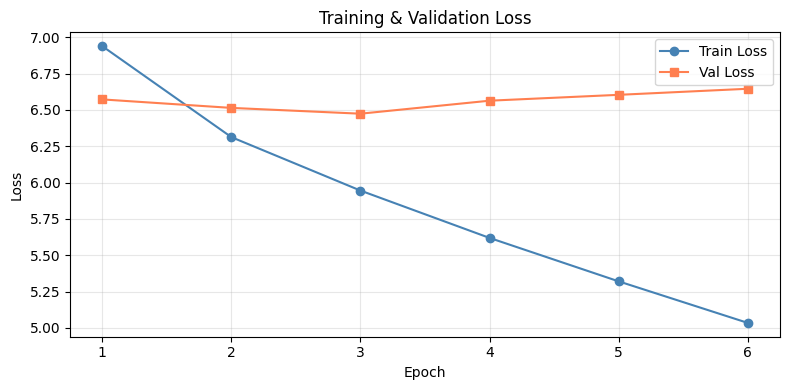

In [6]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs= 15
patience = 3
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        epoch_train_loss += loss.item()

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)
            epoch_val_loss += loss.item()

    avg_train = epoch_train_loss / len(train_loader)
    avg_val = epoch_val_loss   / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)
print(f"\nBest Val Loss: {best_val_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Train Loss', color='steelblue')
plt.plot(range(1, len(val_losses)+1),   val_losses,   marker='s', label='Val Loss',   color='coral')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Text Generation

In [7]:
def generate_text(model, seed_text, vocab, idx2word, num_words=100, temperature=1.0):
    model.eval()
    seed_tokens = seed_text.lower().split()
    seed_encoded = [vocab.get(word, 1) for word in seed_tokens]
    window = [0] * (99 - len(seed_encoded)) + seed_encoded
    window = window[-99:]
    generated_words = seed_tokens.copy()

    with torch.no_grad():
        for _ in range(num_words):
            x = torch.tensor([window], dtype=torch.long).to(device)
            output = model(x) / temperature
            probs  = torch.softmax(output, dim=1)
            next_idx = torch.multinomial(probs, num_samples=1).item()
            generated_words.append(idx2word.get(next_idx, '<UNK>'))
            window = window[1:] + [next_idx]

    return " ".join(generated_words)


seed = "the monster looked at me with"
print("=" * 60)
print(f"Seed: '{seed}'")
print("=" * 60)

for temp in [0.5, 1.0, 1.5]:
    print(f"\nTemperature {temp}:")
    print(generate_text(model, seed, vocab, idx2word, num_words=100, temperature=temp))

Seed: 'the monster looked at me with'

Temperature 0.5:
the monster looked at me with the bitterest of the existence of the room where the old man, at the same feelings and soul, in the morning, of my heart; i was a free and was unable to the open sea. of the cottage and the old man, i do not suppose, to the horror of the old man, of the stars of the union. of marrying of the same opinion, and a mist who had before my protectors. i found my friend, i have been my first victim. in my own room. i was capable but i will be a year of my hands. one

Temperature 1.0:
the monster looked at me with every part of his constant dear, accidents control me that science on the fishermen that if you have offer me at you. and sister who always often no misdeed. on the morning; direction expressed he rendered events and loathing the exceedingly absence to come the sound of you in one else formed. without visit made by several owe i departed. you know, upon my scene. his appearing and i must happily thi

# Analysis

ANALYSIS

Best Train Loss: 5.0341
Best Val Loss:   6.4745
Train Perplexity: 153.6
Val Perplexity:   648.4

<UNK> statistics:
  Temperature 0.5: 0 <UNK> (0.0%)
  Temperature 1.0: 0 <UNK> (0.0%)
  Temperature 1.5: 0 <UNK> (0.0%)


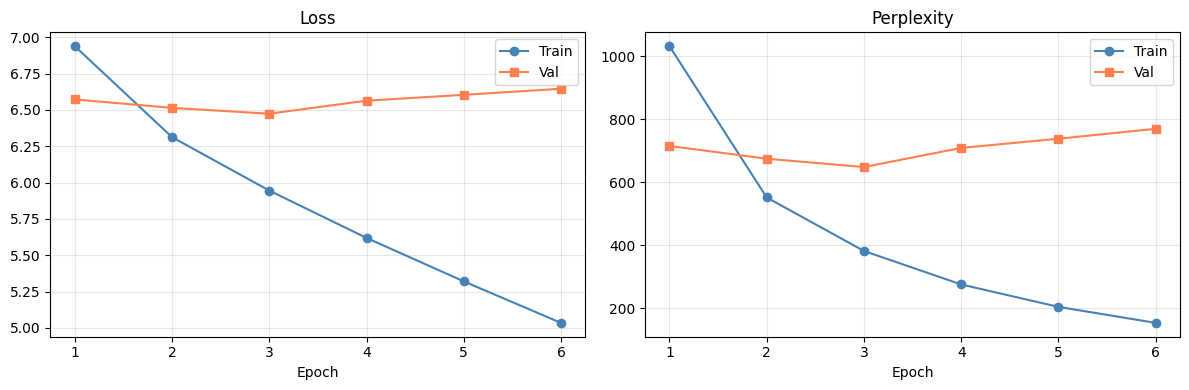

In [9]:
print("=" * 60)
print("ANALYSIS")
print("=" * 60)

print(f"\nBest Train Loss: {min(train_losses):.4f}")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Train Perplexity: {np.exp(min(train_losses)):.1f}")
print(f"Val Perplexity: {np.exp(best_val_loss):.1f}")

print("\n<UNK> statistics:")
for temp in [0.5, 1.0, 1.5]:
    text = generate_text(model, seed, vocab, idx2word, num_words=100, temperature=temp)
    words = text.split()
    unk = words.count('<UNK>')
    print(f"  Temperature {temp}: {unk} <UNK> ({unk/len(words)*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Train', color='steelblue')
ax1.plot(range(1, len(val_losses)+1),   val_losses,   marker='s', label='Val',   color='coral')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

train_perp = [np.exp(l) for l in train_losses]
val_perp = [np.exp(l) for l in val_losses]
ax2.plot(range(1, len(train_perp)+1), train_perp, marker='o', label='Train', color='steelblue')
ax2.plot(range(1, len(val_perp)+1),   val_perp,   marker='s', label='Val',   color='coral')
ax2.set_title('Perplexity')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
